In [1]:
import numpy as np
from matplotlib import pyplot as plt

import sklearn
import requests

from sklearn.cluster import KMeans
from sklearn import preprocessing
from sklearn.neighbors import KernelDensity
from sklearn.mixture import GaussianMixture

In [2]:
r = requests.get('https://user-web.icecube.wisc.edu/~grbweb_public/Summary_table.txt')
with open("Summary_table.txt", 'wb') as f:
    f.write(r.content)

# Read content
data = np.loadtxt("Summary_table.txt", dtype='str',unpack='True')

# Read headers
with open("Summary_table.txt",'r') as f:
    names = np.array([n.strip().replace(" ","_") for n in f.readlines()[1].replace("#","").replace("\n","").lstrip().split('    ') if n.strip()!=''])

In [3]:
names

array(['GRB_name', 'GRB_name_Fermi', 'T0', 'ra', 'decl', 'pos_error',
       'T90', 'T90_error', 'T90_start', 'fluence', 'fluence_error',
       'redshift', "'T100'", 'GBM_located', 'mjd_(T0)'], dtype='<U14')

In [4]:
t90 = np.array(data[6], dtype=float)
t100 = np.array(data[12], dtype=float)
fluence = np.array(data[9], dtype=float)
redshift = np.array(data[11], dtype=float)

In [5]:
fluence_clean = fluence[((fluence != -999) & (t90 != -999) & (fluence != 0))]
t90_clean = t90[((fluence != -999) & (t90 != -999) & (fluence != 0))]

In [6]:
fluence_100_clean = fluence[((fluence != -999) & (t100 != -999) & (fluence != 0))]
t100_clean = t100[((fluence != -999) & (t100 != -999) & (fluence != 0))]

In [7]:
redshift_clean = redshift[((redshift != -999) & (t90 != -999) & (fluence > 0))] # is one type closer/more recent? 
t90_r_clean = t90[((redshift != -999) & (t90 != -999) & (fluence > 0))]
fluence_r_clean = fluence[((redshift != -999) & (t90 != -999) & (fluence > 0))]

In [8]:
grb = dict(zip(names,data))
for lab in ['T90',"redshift","T90_error"]:
    grb[lab] = np.array(grb[lab],dtype='float')

Text(0.5, 0, 't [s]')

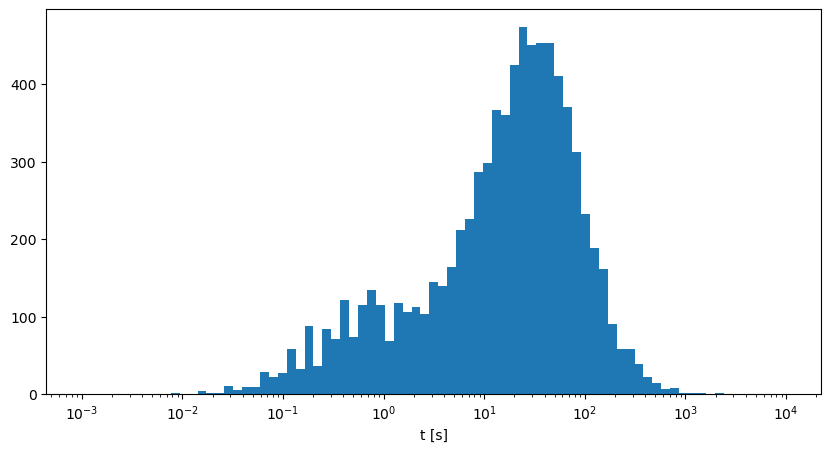

In [9]:
fig,ax = plt.subplots(figsize=(10,5))
plt.hist(grb['T90'],bins= np.logspace(-3,4,80))
plt.xscale('log')
plt.xlabel('t [s]')

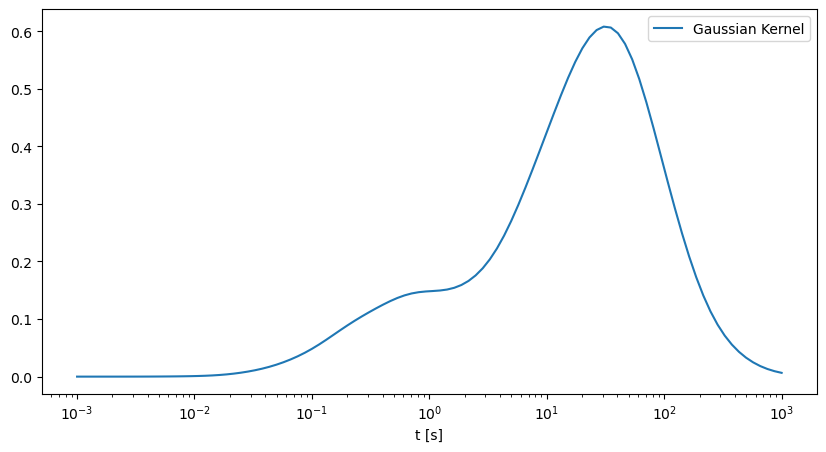

In [10]:
lt90_clean = np.log10(t90_clean)
skt90_clean = lt90_clean[:,np.newaxis]

kde = KernelDensity(kernel='gaussian', bandwidth=0.2).fit(skt90_clean)
xgrid = np.logspace(-3,3,100)

# Rememember score_samples is the log-likelohood. Neep an exp in front
ygrid = np.exp(kde.score_samples(np.log10(xgrid)[:,np.newaxis]))

fig,ax = plt.subplots(figsize=(10,5))

plt.xlabel('t [s]')
plt.plot(xgrid,ygrid,label='Gaussian Kernel')
plt.xscale('log')
plt.legend()

In [11]:
from sklearn.model_selection import GridSearchCV

In [12]:
params = {"bandwidth": np.logspace(-1, 1, 20)}
grid = GridSearchCV(KernelDensity(), params)
grid.fit(skt90_clean)
print("best bandwidth: {0}".format(grid.best_estimator_.bandwidth))

best bandwidth: 0.12742749857031338


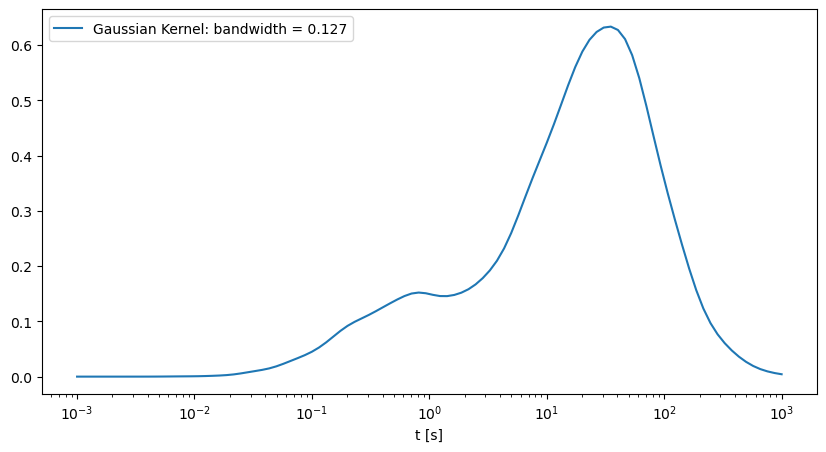

In [13]:
best_bw = grid.best_estimator_.bandwidth
kde = KernelDensity(kernel='gaussian', bandwidth=best_bw).fit(skt90_clean)
xgrid = np.logspace(-3,3,100)

# Rememember score_samples is the log-likelohood. Neep an exp in front
ygrid = np.exp(kde.score_samples(np.log10(xgrid)[:,np.newaxis]))

fig,ax = plt.subplots(figsize=(10,5))

plt.xlabel('t [s]')
plt.plot(xgrid,ygrid,label='Gaussian Kernel: bandwidth = %.3f' % (best_bw))
plt.xscale('log')
plt.legend()

Text(0, 0.5, 'fluence')

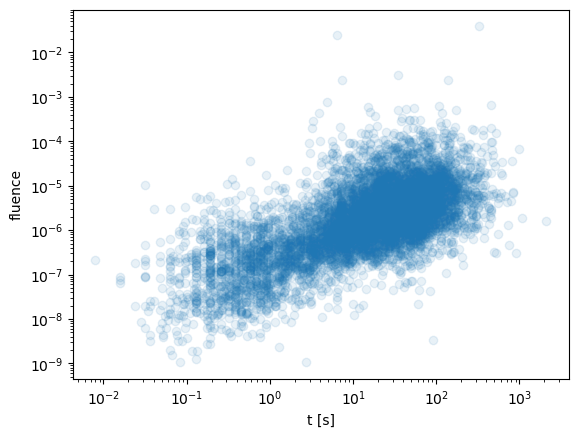

In [14]:
plt.scatter(t90_clean,fluence_clean,alpha=0.1)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('t [s]')
plt.ylabel('fluence')

Text(0.5, 0, 'z')

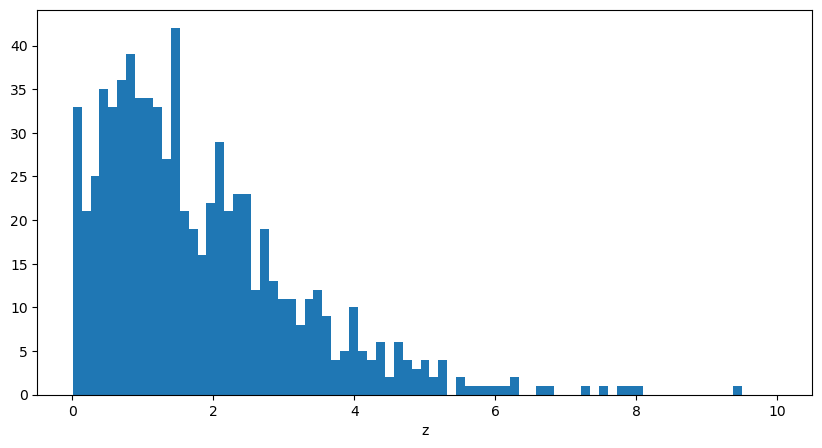

In [15]:
fig,ax = plt.subplots(figsize=(10,5))
plt.hist(grb['redshift'],bins= np.linspace(0.005,10,80))

# plt.hist(grb['redshift'],bins= np.logspace(5e-3,1,80))
# plt.xscale('log')
plt.xlabel('z')

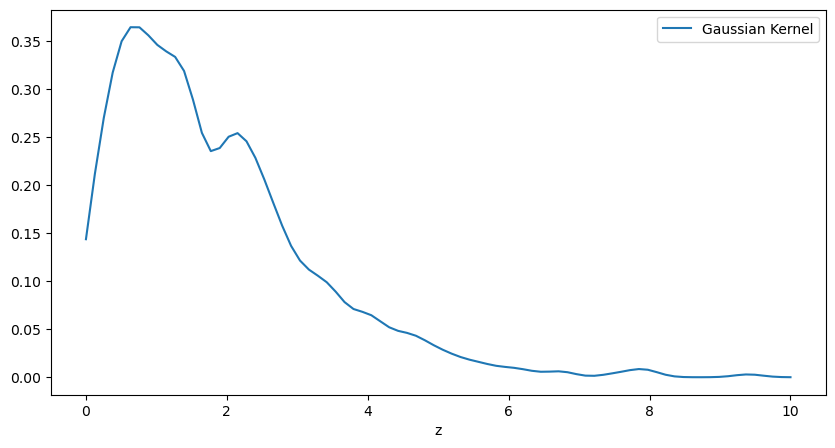

In [16]:
skz_clean = redshift_clean[:,np.newaxis]

kdez = KernelDensity(kernel='gaussian', bandwidth=0.2).fit(skz_clean)
xgrid_z = np.linspace(0.005,10,80)

# Rememember score_samples is the log-likelohood. Neep an exp in front
ygrid_z = np.exp(kdez.score_samples((xgrid_z)[:,np.newaxis]))

fig,ax = plt.subplots(figsize=(10,5))

plt.xlabel('z')
plt.plot(xgrid_z,ygrid_z,label='Gaussian Kernel')
plt.legend()

In [17]:
params = {"bandwidth": np.logspace(-1, 1, 20)}
grid = GridSearchCV(KernelDensity(), params)
grid.fit(skz_clean)
print("best bandwidth: {0}".format(grid.best_estimator_.bandwidth))

best bandwidth: 0.5455594781168519


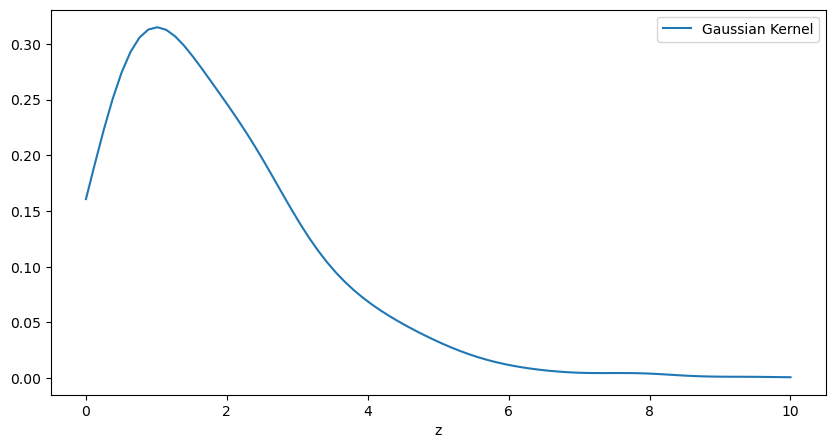

In [18]:
best_bw = grid.best_estimator_.bandwidth
kdez = KernelDensity(kernel='gaussian', bandwidth=best_bw).fit(skz_clean)
xgrid_z = np.linspace(0.005,10,80)

# Rememember score_samples is the log-likelohood. Neep an exp in front
ygrid_z = np.exp(kdez.score_samples((xgrid_z)[:,np.newaxis]))

fig,ax = plt.subplots(figsize=(10,5))

plt.xlabel('z')
plt.plot(xgrid_z,ygrid_z,label='Gaussian Kernel')
plt.legend()

Text(0, 0.5, 'z')

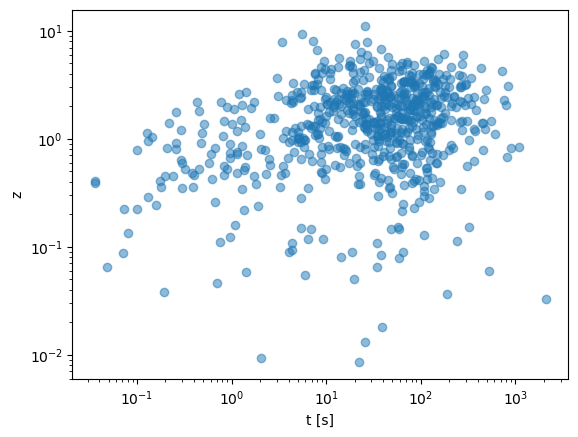

In [19]:
plt.scatter(t90_r_clean,redshift_clean,alpha=0.5)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('t [s]')
plt.ylabel('z')

K-Means
-

Text(0, 0.5, 'log(fluence [$erg/cm^2\t$])')

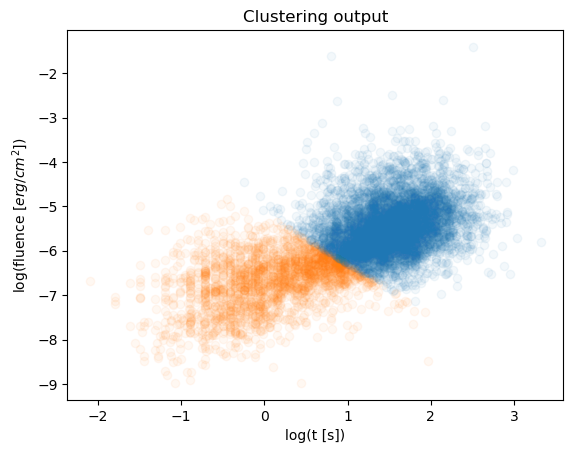

In [20]:
X = np.array([np.log10(t90_clean), np.log10(fluence_clean)])
X = X.T
clf = KMeans(n_clusters=2,n_init='auto') #Try 2 clusters to start with
clf.fit(X)
centers = clf.cluster_centers_ #location of the clusters
labels = clf.predict(X) #labels for each of the points

# plot the data color-coded by cluster id
colors = ['C1', 'C0', 'C2']
for ii in range(2):
    plt.scatter(X[labels==ii,0], X[labels==ii,1], 
                color=colors[ii],alpha=0.05)

plt.title(r'Clustering output')

plt.xlabel('log(t [s])')
plt.ylabel(r'log(fluence [$erg/cm^2	$])')

In [21]:
centers = 10**np.squeeze(centers)
edge = 10**( np.mean( [max(X[labels==0,0]), min(X[labels==1,0]) ]))

[[1.22994633e+00 2.01742636e-07]
 [3.36680588e+01 3.63210226e-06]]


Text(0.5, 0, 'log(t [s])')

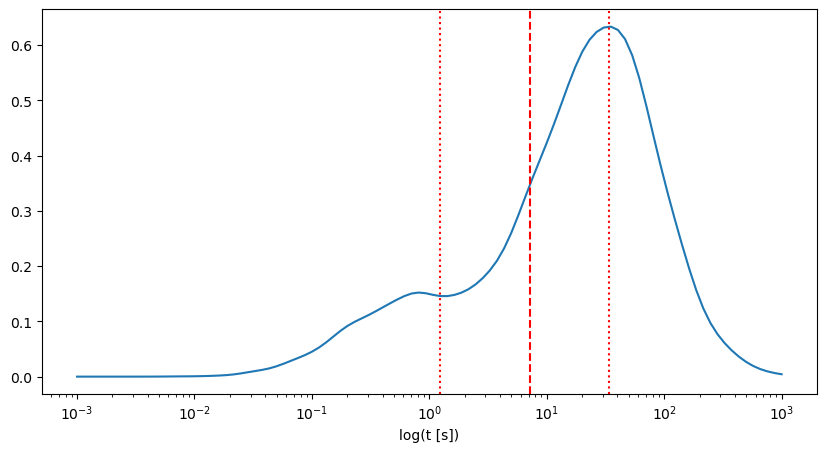

In [22]:
fig,ax = plt.subplots(figsize=(10,5))

plt.plot(xgrid,ygrid)
plt.semilogx()
for v in centers:
    plt.axvline(v[0], c='red',ls='dotted')
plt.axvline(edge,c='red',ls='dashed')
print(centers)
plt.xlabel('log(t [s])')


[]

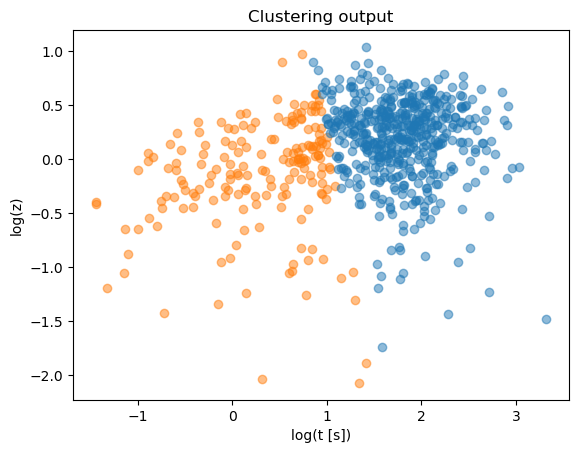

In [23]:
Y = np.array([np.log10(t90_r_clean), np.log10(redshift_clean)])
Y = Y.T
clf = KMeans(n_clusters=2,n_init='auto') #Try 2 clusters to start with
clf.fit(Y)
centers2 = clf.cluster_centers_ #location of the clusters
labels2 = clf.predict(Y) #labels for each of the points

# plot the data color-coded by cluster id
colors = ['C1', 'C0', 'C2']
for ii in range(2):
    plt.scatter(Y[labels2==ii,0], Y[labels2==ii,1], 
                color=colors[ii],alpha=0.5)

plt.title(r'Clustering output')

plt.xlabel('log(t [s])')
plt.ylabel(r'log(z)')
plt.plot()

In [24]:
centers2 = 10**np.squeeze(centers2)
edge2 = 10**( np.mean( [max(Y[labels2==0,0]), min(Y[labels2==1,0]) ]))

[[ 2.00179297  0.70886451]
 [61.6069729   1.5534979 ]]


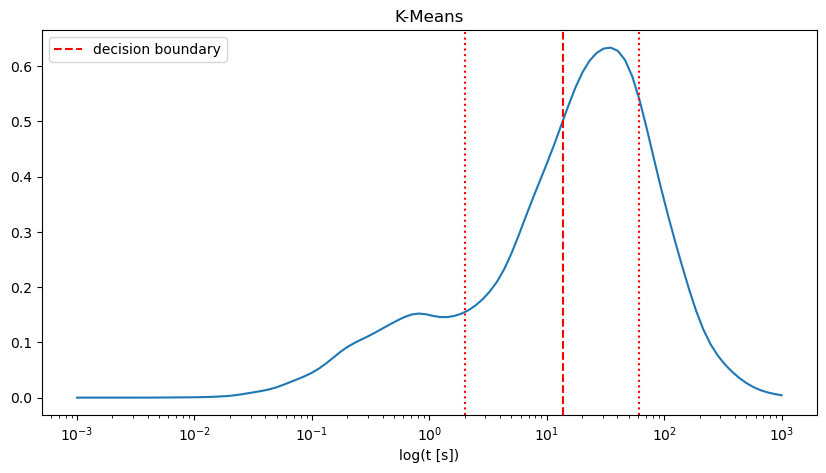

In [25]:
fig,ax = plt.subplots(figsize=(10,5))

plt.plot(xgrid,ygrid)
plt.semilogx()
for v in centers2:
    plt.axvline(v[0], c='red',ls='dotted')
plt.axvline(edge2,c='red',ls='dashed',label='decision boundary')
print(centers2)
plt.xlabel('log(t [s])')
plt.legend()
plt.title('K-Means');

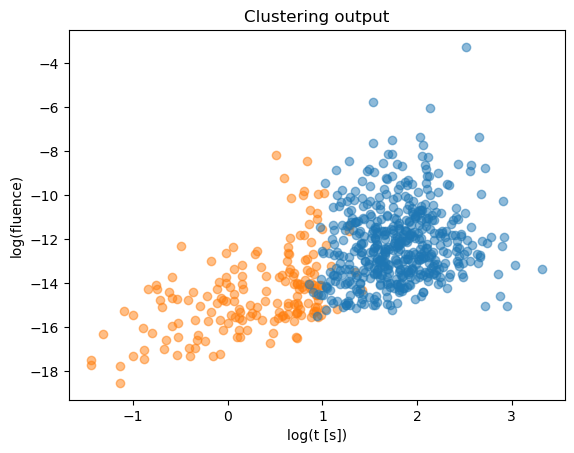

In [26]:
for ii in range(2):
    plt.scatter(Y[labels2==ii,0], np.log(fluence_r_clean[labels2==ii]), 
                color=colors[ii],alpha=0.5)

plt.title(r'Clustering output')

plt.xlabel('log(t [s])')
plt.ylabel(r'log(fluence)');

Mean shift
-

In [27]:
from sklearn.cluster import MeanShift

scaler = preprocessing.StandardScaler()
bandwidth = 0.4
ms = MeanShift(bandwidth=bandwidth, 
               bin_seeding=True, 
               cluster_all=False,
               min_bin_freq=60
              )
ms.fit(scaler.fit_transform(X))

MeanShift(bandwidth=0.4, bin_seeding=True, cluster_all=False, min_bin_freq=60)

[-1  0  1]
0.4
number of estimated clusters : 2


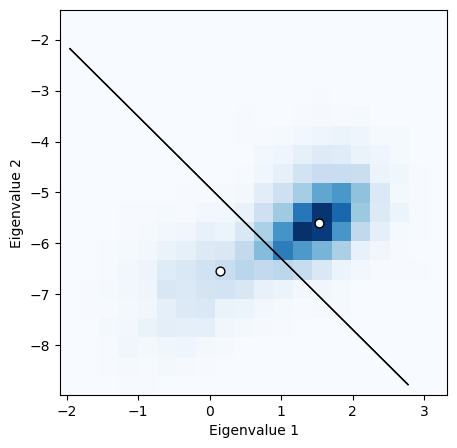

In [28]:
labels_unique, counts = np.unique(ms.labels_, return_counts=True)
n_clusters = len(labels_unique[labels_unique >= 0])
print(labels_unique)
print(bandwidth)
print("number of estimated clusters :", n_clusters)

# Make some plots
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot()

# Compute a 2D histogram  of the input
H, xedges, yedges = np.histogram2d(X[:,0], X[:,1], 20)

# plot density
ax.imshow(H.T, origin='lower', interpolation='nearest', aspect='auto',
          extent=[xedges[0], xedges[-1],
                  yedges[0], yedges[-1]],
          cmap='Blues')

# plot cluster centers
cluster_centers = scaler.inverse_transform(ms.cluster_centers_)
ax.scatter(cluster_centers[:, 0], cluster_centers[:, 1],
           s=40, c='w', edgecolors='k')

# plot cluster boundaries
x_centers = 0.5 * (xedges[1:] + xedges[:-1])
y_centers = 0.5 * (yedges[1:] + yedges[:-1])

Xgrid = np.meshgrid(x_centers, y_centers)
Xgrid = np.array(Xgrid).reshape((2, 20 * 20)).T

H = ms.predict(scaler.transform(Xgrid)).reshape((20, 20))

for i in range(n_clusters):
    Hcp = H.copy()
    flag = (Hcp == i)
    Hcp[flag] = 1
    Hcp[~flag] = 0

    ax.contour(x_centers, y_centers, Hcp, [-0.5, 0.5],
               linewidths=1, colors='k')
 
    H = ms.predict(scaler.transform(Xgrid)).reshape((20, 20))
    
ax.set_xlim(xedges[0], xedges[-1])
ax.set_ylim(yedges[0], yedges[-1])

ax.set_xlabel('Eigenvalue 1')
ax.set_ylabel('Eigenvalue 2')

plt.show()    

In [29]:
10**cluster_centers[:, 0]

array([33.26202031,  1.39814852])

In [30]:
centers3 = 10**cluster_centers[:, 0]
labels3 = (ms.labels_)
edge3 = 10**( np.mean( [max(X[labels3==0,0]), min(X[labels3==1,0]) ]))

[33.26202031  1.39814852]


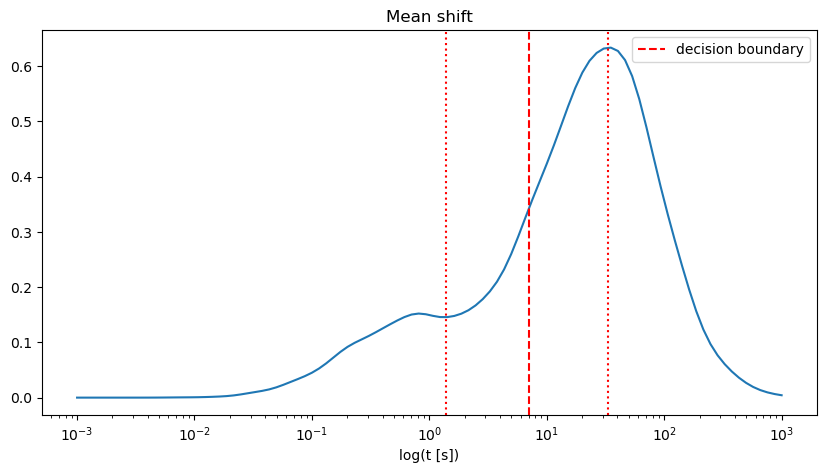

In [31]:
fig,ax = plt.subplots(figsize=(10,5))

plt.plot(xgrid,ygrid)
plt.semilogx()
for v in centers3:
    plt.axvline(v, c='red',ls='dotted')
plt.axvline(edge3,c='red',ls='dashed',label='decision boundary')
print(centers3)
plt.xlabel('log(t [s])')
plt.legend()
plt.title('Mean shift');

In [32]:
counts

array([6366, 1204,  268])

Brief comparison
-

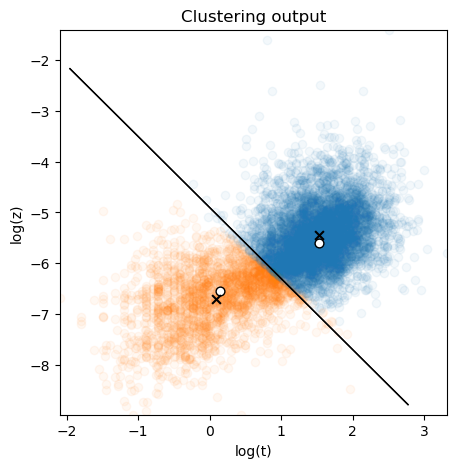

In [33]:
# Make some plots
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot()

# Compute a 2D histogram  of the input
H, xedges, yedges = np.histogram2d(X[:,0], X[:,1], 20)


for ii in range(3):
    plt.scatter(X[labels==ii,0], X[labels==ii,1], 
                color=colors[ii],alpha=0.05)

# plot cluster centers
cluster_centers = scaler.inverse_transform(ms.cluster_centers_)
ax.scatter(cluster_centers[:, 0], cluster_centers[:, 1],
           s=40, c='w', edgecolors='k')
ax.scatter(np.log10(centers[:, 0]), np.log10(centers[:, 1]),
           s=40, marker='x',c='k')


# plot cluster boundaries
x_centers = 0.5 * (xedges[1:] + xedges[:-1])
y_centers = 0.5 * (yedges[1:] + yedges[:-1])

Xgrid = np.meshgrid(x_centers, y_centers)
Xgrid = np.array(Xgrid).reshape((2, 20 * 20)).T

H = ms.predict(scaler.transform(Xgrid)).reshape((20, 20))

for i in range(n_clusters):
    Hcp = H.copy()
    flag = (Hcp == i)
    Hcp[flag] = 1
    Hcp[~flag] = 0

    ax.contour(x_centers, y_centers, Hcp, [-0.5, 0.5],
               linewidths=1, colors='k')
 
    H = ms.predict(scaler.transform(Xgrid)).reshape((20, 20))
    
ax.set_xlim(xedges[0], xedges[-1])
ax.set_ylim(yedges[0], yedges[-1])

plt.title(r'Clustering output')

plt.xlabel('log(t)')
plt.ylabel(r'log(z)');

In [34]:
important_centers_ms = 10**np.array([cluster_centers[:2, 0], cluster_centers[:2, 1]]) # i cluster sono ordinati in modo decrescente sulla base di densità di punti
important_centers_ms = important_centers_ms.T
important_centers_ms, centers

(array([[3.32620203e+01, 2.47963223e-06],
        [1.39814852e+00, 2.88128389e-07]]),
 array([[1.22994633e+00, 2.01742636e-07],
        [3.36680588e+01, 3.63210226e-06]]))

In [35]:
print('K-MEANS: \ncenters: t %.3f %.7f' % ((centers[0, 0]), (centers[0, 1])))
print('SHIFT MEAN: \ncenters: t %.3f %.7f' % (important_centers_ms[0,0], important_centers_ms[0,1]))

K-MEANS: 
centers: t 1.230 0.0000002
SHIFT MEAN: 
centers: t 33.262 0.0000025


In [36]:
print('K-MEANS: \ncenters: cluster 1: ' + str(centers[0, :]) + ' cluster 2: ' + str(centers[1, :]))
print('SHIFT MEAN: \ncenters: cluster 1: ' + str(important_centers_ms[0,:]) + ' cluster 2: ' + str(important_centers_ms[1,:]))

K-MEANS: 
centers: cluster 1: [1.22994633e+00 2.01742636e-07] cluster 2: [3.36680588e+01 3.63210226e-06]
SHIFT MEAN: 
centers: cluster 1: [3.32620203e+01 2.47963223e-06] cluster 2: [1.39814852e+00 2.88128389e-07]
